<a href="https://colab.research.google.com/github/ryanrtrindade/linear_salario/blob/C%C3%B3digos/RegressaoLinearRev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
#Ola, nesse projeto veremos uma breve construção de modelo regressão linear de um dataset para prever salários baseado no tempo de experiência de trabalho

In [101]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/PYTHON/Salary_Data.csv")

In [102]:
#Antes de tudo, como boa prática é fundamental que façamos uma breve checagem no dataset para obter algumas informações sobre sua integridade
#Iremo verificar se há valores nulos, duplicados e outliers

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [103]:
df.isnull().sum(0)

,0
YearsExperience,0
Salary,0


In [104]:
df.duplicated().sum()

np.int64(0)

In [105]:
df.dtypes

,0
YearsExperience,float64
Salary,float64


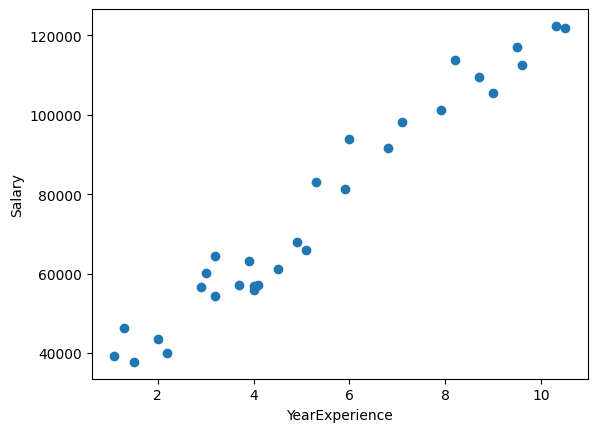

In [106]:
#verificação do local dos dados

import matplotlib.pyplot as plt

plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('YearExperience')
plt.ylabel('Salary')
plt.show()

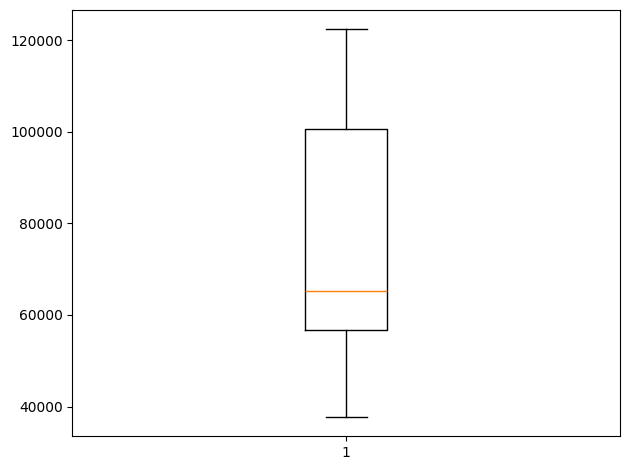

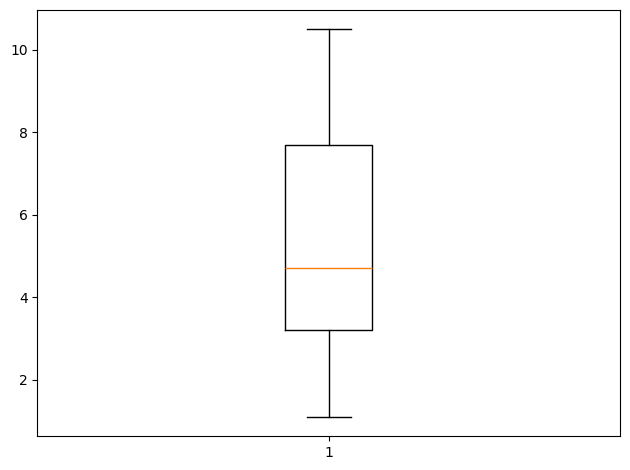

In [107]:
#Verificação de outliers

plt.boxplot(df[ 'Salary'])
plt.tight_layout()
plt.show()

plt.boxplot(df[ 'YearsExperience'])
plt.tight_layout()
plt.show()

In [108]:
#Agora que não há outliers ou a necessidade de tratar dados duplicados ou nulos, é hora de construir e treinar o modelo

In [109]:
#1 Passo - Importar a biblioteca train_test_split para dividir os dados para treinamento e teste

from sklearn.model_selection import train_test_split
#2- Passo - Vamos separar as variaveis independentes e dependentes, onde x é a váriavel independente e y a dependente(váraivel resposta que queremos prever)

x = df.drop(['Salary'], axis = 1)
y = df.Salary

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

#x_train e y_train são variaveis para o modelo treinar, enquanto x_test e y_test são para medir o desempenho do modelo
#test_size = 0.3 é basicamente separar o modelo em 70% para treino e 30% teste, se fosse 0.2 seria 80% treino e 20% teste

In [110]:
#Aqui será a construção do modelo
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
#Treinando o modelo, aqui o modelo vai aprender com 70% dos dados de treino
modelo.fit(x_train, y_train)

LinearRegression()

In [111]:
#Atribuindo a uma variavel nossa previsão do modelo

#imagina que x_test é a prova com questões
y_pred = modelo.predict(x_test)

In [112]:
from sklearn.metrics import  r2_score

#essa métrica vai ser a correlação entre o resultado real(y_test) e a previsão(y_pred), quanto mais próximo de 1.0 melhor!
#de maneira didática, y_test é o gabarito e y_pred as suas respostas na prova(x_test)

r2_score(y_test, y_pred)


0.9740993407213511

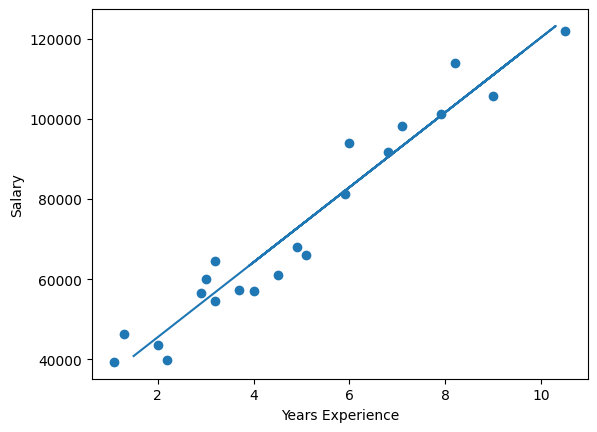

In [113]:
#a por último, a visualização gráfica

#valores reais
plt.scatter(x_train, y_train)
#reta(valores previstos)
plt.plot(x_test, y_pred)
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.show()